# Notebook 17 — Neural Network Baseline

**Autor:** Nassim Groppe
**Modul:** DBU Data Analyst I
**Datum:** August 2026

## Zweck

Erweiterung des Random-Forest-Ansatzes aus Notebook 15 um ein neuronales Netz zur Prüfung der Robustheit der Kernergebnisse gegenüber der Modellwahl.

## Methodik

- **Identische Features** wie Random Forest: 8 technische Indikatoren
- **Identische Target-Konstruktion**: Forward_Return_1W via `shift(-5)/s - 1`
- **Identische Hold-Out-Trennung**: Training bis 2023-12-31, Test ab 2024-01-01
- **Standardisierung**: `StandardScaler` (fit nur auf Training)
- **Architektur**: Multi-Layer Perceptron (64 → 32 → 16 → 1)
- **Regularisierung**: Dropout (p=0.2), L2 (weight_decay=1e-4), Early Stopping

## Erwartung

Falls die Kernerkenntnis (Underperformance des Baskets aus rein preisbasierten Features) robust ist, sollte auch das NN keine signifikante Outperformance erzeugen. Ein positives NN-Ergebnis würde dagegen die These der schwachen EMH herausfordern.


In [1]:
# ============================================================
# Imports und globale Konstanten
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# STRIKTE HOLD-OUT-TRENNUNG — identisch zu Notebook 15
TRAIN_END = "2023-12-31"
TEST_START = "2024-01-01"

# Reproduzierbarkeit
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Feature-Liste — IDENTISCH zu Notebook 15 (Random Forest)
FEATURES = [
    'Daily_Return',
    'Momentum_3M', 'Momentum_6M', 'Momentum_12M',
    'Volatility_30d',
    'MA_50', 'MA_200',
    'RSI_14'
]
TARGET = 'Forward_Return_1W'

# Device für PyTorch (M-Chip nutzt MPS)
DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

print(f"Device: {DEVICE}")
print(f"Features: {len(FEATURES)} technische Indikatoren")
print(f"Target: {TARGET}")
print(f"Split: Train bis {TRAIN_END}, Test ab {TEST_START}")


Device: mps
Features: 8 technische Indikatoren
Target: Forward_Return_1W
Split: Train bis 2023-12-31, Test ab 2024-01-01


In [2]:
# ============================================================
# Daten laden und Target berechnen
# ============================================================
# Basket-Features laden (identisch zu Notebook 15)
basket = pd.read_parquet('../data/processed/basket_features.parquet')
print(f"Original Shape: {basket.shape}")

# Forward_Return_1W berechnen — 5 Handelstage
# Konstruktion IDENTISCH zu Notebook 15 (Konsistenz für fairen Vergleich)
basket = basket.sort_values(['Ticker', 'Date']).copy()
basket['Forward_Return_1W'] = (
    basket.groupby('Ticker')['Close']
    .transform(lambda s: s.shift(-5) / s - 1)
)

print(f"Forward_Return_1W berechnet")
print(f"Gültige Zielwerte: {basket['Forward_Return_1W'].notna().sum():,} / {len(basket):,}")

# NaN-Filter: Features und Target müssen vorhanden sein
basket_clean = basket.dropna(subset=FEATURES + [TARGET]).copy()
print(f"Nach NaN-Filter: {basket_clean.shape}")
print(f"Verworfen: {len(basket) - len(basket_clean):,} Zeilen "
      f"({(len(basket) - len(basket_clean))/len(basket)*100:.1f}%)")

Original Shape: (120480, 25)
Forward_Return_1W berechnet
Gültige Zielwerte: 120,080 / 120,480
Nach NaN-Filter: (120080, 26)
Verworfen: 400 Zeilen (0.3%)


In [3]:
# ============================================================
# Zeitliche Trennung und Standardisierung
# ============================================================
# STRIKTE zeitliche Trennung — verhindert Look-Ahead-Bias
train = basket_clean[basket_clean['Date'] <= TRAIN_END].copy()
test = basket_clean[basket_clean['Date'] >= TEST_START].copy()

print("--- Split-Statistiken ---")
print(f"Training: {train['Date'].min().date()} bis {train['Date'].max().date()}")
print(f"          {len(train):,} Zeilen")
print(f"Test:     {test['Date'].min().date()} bis {test['Date'].max().date()}")
print(f"          {len(test):,} Zeilen")

# Feature-Matrizen extrahieren
X_train = train[FEATURES].values
y_train = train[TARGET].values
X_test = test[FEATURES].values
y_test = test[TARGET].values

# Standardisierung — KRITISCH: fit NUR auf Training!
# Ein fit_transform auf Testdaten wäre Look-Ahead-Bias auf Feature-Ebene
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print()
print("--- Nach Standardisierung ---")
print(f"X_train — Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"X_test  — Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")
print("(Testwerte leicht abweichend von 0/1 = korrektes Fitting-Verhalten)")


--- Split-Statistiken ---
Training: 2020-01-03 bis 2023-12-29
          81,600 Zeilen
Test:     2024-01-02 bis 2025-11-19
          38,480 Zeilen

--- Nach Standardisierung ---
X_train — Mean: -0.0000, Std: 1.0000
X_test  — Mean: 0.0501, Std: 1.2130
(Testwerte leicht abweichend von 0/1 = korrektes Fitting-Verhalten)


In [4]:
# ============================================================
# BasketNN — Multi-Layer Perceptron
# ============================================================
class BasketNN(nn.Module):
    """
    Multi-Layer Perceptron zur Prognose der Wochenrendite.

    Architektur:
        Input:    8 Features
        Hidden 1: 64 Neuronen  + ReLU + Dropout(0.2)
        Hidden 2: 32 Neuronen  + ReLU + Dropout(0.2)
        Hidden 3: 16 Neuronen  + ReLU + Dropout(0.2)
        Output:   1 Neuron (Regression, keine Aktivierung)

    Regularisierung:
        - Dropout intern (p=0.2)
        - L2-Regularisierung extern via Optimizer (weight_decay)
        - Early Stopping extern
    """

    def __init__(self, input_dim=8, hidden_dims=[64, 32, 16], dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Output-Layer ohne Aktivierung (Regression)
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Modell instanziieren
model = BasketNN(
    input_dim=len(FEATURES),
    hidden_dims=[64, 32, 16],
    dropout=0.2
).to(DEVICE)

# Modell-Überblick
print(model)
print()

# Parameter zählen
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainierbare Parameter: {n_params:,}")

BasketNN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

Trainierbare Parameter: 3,201


Training startet...
-------------------------------------------------------
Epoche   0 | Loss: 0.039087
Epoche  25 | Loss: 0.007630
Epoche  50 | Loss: 0.005749
Epoche  75 | Loss: 0.005047
Epoche 100 | Loss: 0.004609
Epoche 125 | Loss: 0.004309
Epoche 150 | Loss: 0.004088
Epoche 175 | Loss: 0.003940
Epoche 200 | Loss: 0.003825
Epoche 225 | Loss: 0.003745
Epoche 250 | Loss: 0.003642
Epoche 275 | Loss: 0.003578
Epoche 300 | Loss: 0.003560
Epoche 325 | Loss: 0.003492
Epoche 350 | Loss: 0.003455
Epoche 375 | Loss: 0.003390
Epoche 400 | Loss: 0.003341
Epoche 425 | Loss: 0.003297
Epoche 450 | Loss: 0.003266
Epoche 475 | Loss: 0.003251
-------------------------------------------------------
Training abgeschlossen. Bester Loss: 0.003222
Modell gespeichert: ../models/nn_baseline.pt


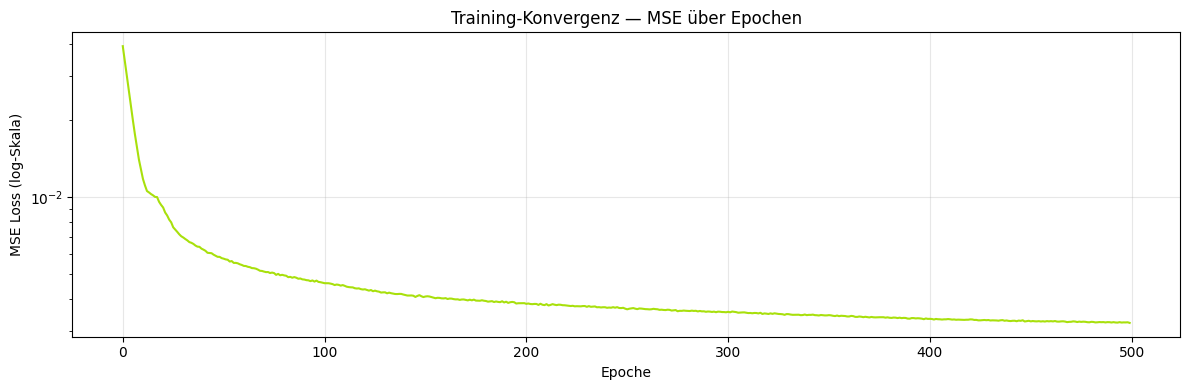

In [5]:
# ============================================================
# Training-Loop
# ============================================================
# Tensoren auf Device
X_train_tensor = torch.FloatTensor(X_train_scaled).to(DEVICE)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1).to(DEVICE)

# Loss und Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,           # Lernrate
    weight_decay=1e-4   # L2-Regularisierung
)

# Training-Konfiguration
EPOCHS = 500
PATIENCE = 30
best_loss = float('inf')
patience_counter = 0
loss_history = []

print("Training startet...")
print("-" * 55)

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # Early Stopping
    if loss.item() < best_loss:
        best_loss = loss.item()
        patience_counter = 0
        torch.save(model.state_dict(), '../models/nn_baseline.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early Stopping bei Epoche {epoch}")
            break

    if epoch % 25 == 0:
        print(f"Epoche {epoch:3d} | Loss: {loss.item():.6f}")

print("-" * 55)
print(f"Training abgeschlossen. Bester Loss: {best_loss:.6f}")
print(f"Modell gespeichert: ../models/nn_baseline.pt")

# Loss-Curve plotten
plt.figure(figsize=(12, 4))
plt.plot(loss_history, color='#A8E00C', linewidth=1.5)
plt.title('Training-Konvergenz — MSE über Epochen', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('MSE Loss (log-Skala)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


OUT-OF-SAMPLE EVALUATION — Test-Set 2024-2025
R²    (NN):     -0.010672
R²    (naiv):   -0.000024   ← Baseline: Mittelwert
MSE:             0.002327
RMSE:            0.048236
MAE:             0.034152

Test-Zeitraum: 2024-01-02 bis 2025-11-19
Test-Datenpunkte: 38,480


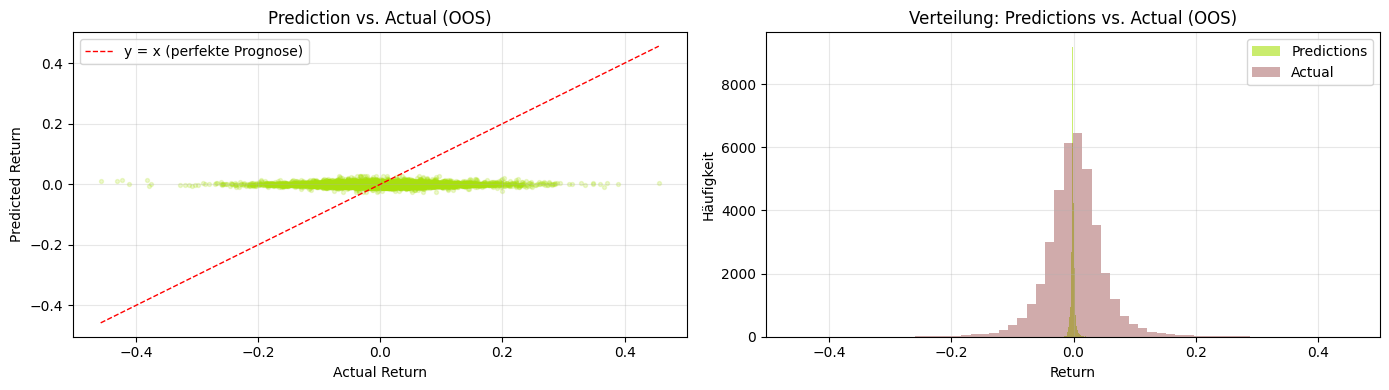


Predictions gespeichert: ../data/processed/predictions_nn_oos.parquet
Shape: (38480, 5)


In [6]:
# ============================================================
# Out-of-Sample Evaluation (Test-Set 2024-2025)
# ============================================================
# Bestes Modell laden
model.load_state_dict(torch.load('../models/nn_baseline.pt'))
model.eval()

# Predictions auf Test-Set
X_test_tensor = torch.FloatTensor(X_test_scaled).to(DEVICE)
with torch.no_grad():
    y_pred_test = model(X_test_tensor).cpu().numpy().flatten()

# Kennzahlen berechnen
r2_oos = r2_score(y_test, y_pred_test)
mse_oos = mean_squared_error(y_test, y_pred_test)
mae_oos = mean_absolute_error(y_test, y_pred_test)
rmse_oos = np.sqrt(mse_oos)

# Vergleich zur naiven Prognose (Mittelwert)
y_naive = np.full_like(y_test, y_train.mean())
r2_naive = r2_score(y_test, y_naive)

print("=" * 55)
print("OUT-OF-SAMPLE EVALUATION — Test-Set 2024-2025")
print("=" * 55)
print(f"R²    (NN):    {r2_oos:>10.6f}")
print(f"R²    (naiv):  {r2_naive:>10.6f}   ← Baseline: Mittelwert")
print(f"MSE:           {mse_oos:>10.6f}")
print(f"RMSE:          {rmse_oos:>10.6f}")
print(f"MAE:           {mae_oos:>10.6f}")
print()
print(f"Test-Zeitraum: {test['Date'].min().date()} bis {test['Date'].max().date()}")
print(f"Test-Datenpunkte: {len(y_test):,}")

# Prediction-Verteilung visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=8, color='#A8E00C')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
              'r--', label='y = x (perfekte Prognose)', linewidth=1)
axes[0].set_xlabel('Actual Return')
axes[0].set_ylabel('Predicted Return')
axes[0].set_title('Prediction vs. Actual (OOS)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_pred_test, bins=60, alpha=0.6, label='Predictions', color='#A8E00C')
axes[1].hist(y_test, bins=60, alpha=0.4, label='Actual', color='#8B2E2E')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung: Predictions vs. Actual (OOS)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Predictions speichern für Notebook 19 (Backtest)
test_out = test[['Date', 'Ticker', 'Close']].copy()
test_out['Actual_Return'] = y_test
test_out['Predicted_Return_NN'] = y_pred_test
test_out.to_parquet('../data/processed/predictions_nn_oos.parquet', index=False)

print()
print(f"Predictions gespeichert: ../data/processed/predictions_nn_oos.parquet")
print(f"Shape: {test_out.shape}")
